# SV enrichment among climate-selected clq0.9 blocks — Manhattans (all-variants vs SNP-only)

2026-07-03. Companion notebook to `phase1_replication/sv_enrichment_clq90.py` +
`sv_polarity_enrichment_clq90.py`. GEA = Kendall-tau + LFMM(K=16) + effective-N binomial,
WZA-aggregated at clq0.9 (r²≥0.9) BigLD blocks, gen9 vs bio1 (`STATUS_clq90.md`).

**Classes**: `nonsnp` = SV+indel pooled ("all variants" beyond SNPs) vs `snp` = SNP-only.
**Question**: are BH-significant blocks enriched for SVs, and specifically for blocks
carrying *both* an insertion-type and deletion-type SV (`both_sv`)?

**Result recap**: `has_sv` alone shows no clean enrichment (McNemar n.s. in all 3 models).
Splitting by polarity: insertion-only and deletion-only SV blocks are flat null everywhere.
But **`both_sv` blocks (co-occurring ins+del SV) are permutation-significant in all 6 runs**
(3 models x {nonsnp,snp}), and binomial's McNemar test — the strictest, matched-pair test —
clears p<0.01 in **both** classes. Direct record-level spot-check confirmed these blocks
genuinely carry both an insertion and a deletion SV. 3 of the 7 recurring `both_sv` BH-sig
blocks (`Chr2_2819`, `Chr3_6144`, `Chr4_6307`) are independently the blocks `STATUS_clq90.md`
already flagged as BH-sig in ALL 3 models AND both classes — the most reproducible climate
blocks in the whole clq0.9 replication.

In [1]:

import numpy as np, pandas as pd
import matplotlib; import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi':120,'font.size':9})

GEA = "/global/scratch/users/tbellg/kmate/results/grenenet_gea"
WZA = f"{GEA}/phase1_replication/clq90/wza"
MODELS = ["kendall", "lfmm", "binomial"]
CLASSES = ["nonsnp", "snp"]   # "all variants" (SV+indel) vs "SNP-only"
CHROM_LEN = {"Chr1": 30427671, "Chr2": 19698289, "Chr3": 23459830,
             "Chr4": 18585056, "Chr5": 26975502}

def bh(p):
    p = np.asarray(p, float); n = len(p); o = np.argsort(p); q = np.empty(n)
    q[o] = (p[o] * n) / (np.arange(n) + 1)
    q[o] = np.minimum.accumulate(q[o][::-1])[::-1]
    return np.clip(q, 0, 1)

def offsets():
    off, cum = {}, 0
    for c in ["Chr1","Chr2","Chr3","Chr4","Chr5"]:
        off[c] = cum; cum += CHROM_LEN[c]
    return off, cum
OFF, TOTAL = offsets()

comp = pd.read_csv(f"{GEA}/driver_passenger/block_composition_kendall_gen9_bio1.csv")
pol = pd.read_csv(f"{GEA}/phase1_replication/clq90/block_polarity_composition.csv")
pol_full = comp[["block","has_sv"]].merge(pol, on="block", how="left").fillna(0)
pol_full["both_sv"] = (pol_full.n_ins_sv > 0) & (pol_full.n_del_sv > 0)
print(f"blocks: {len(comp):,} | has_sv {int(comp.has_sv.sum()):,} | both_sv {int(pol_full.both_sv.sum()):,}")


blocks: 58,308 | has_sv 5,768 | both_sv 1,279


wrote /global/scratch/users/tbellg/kmate/results/grenenet_gea/phase1_replication/clq90/manhattan_sv_polarity_clq90.png


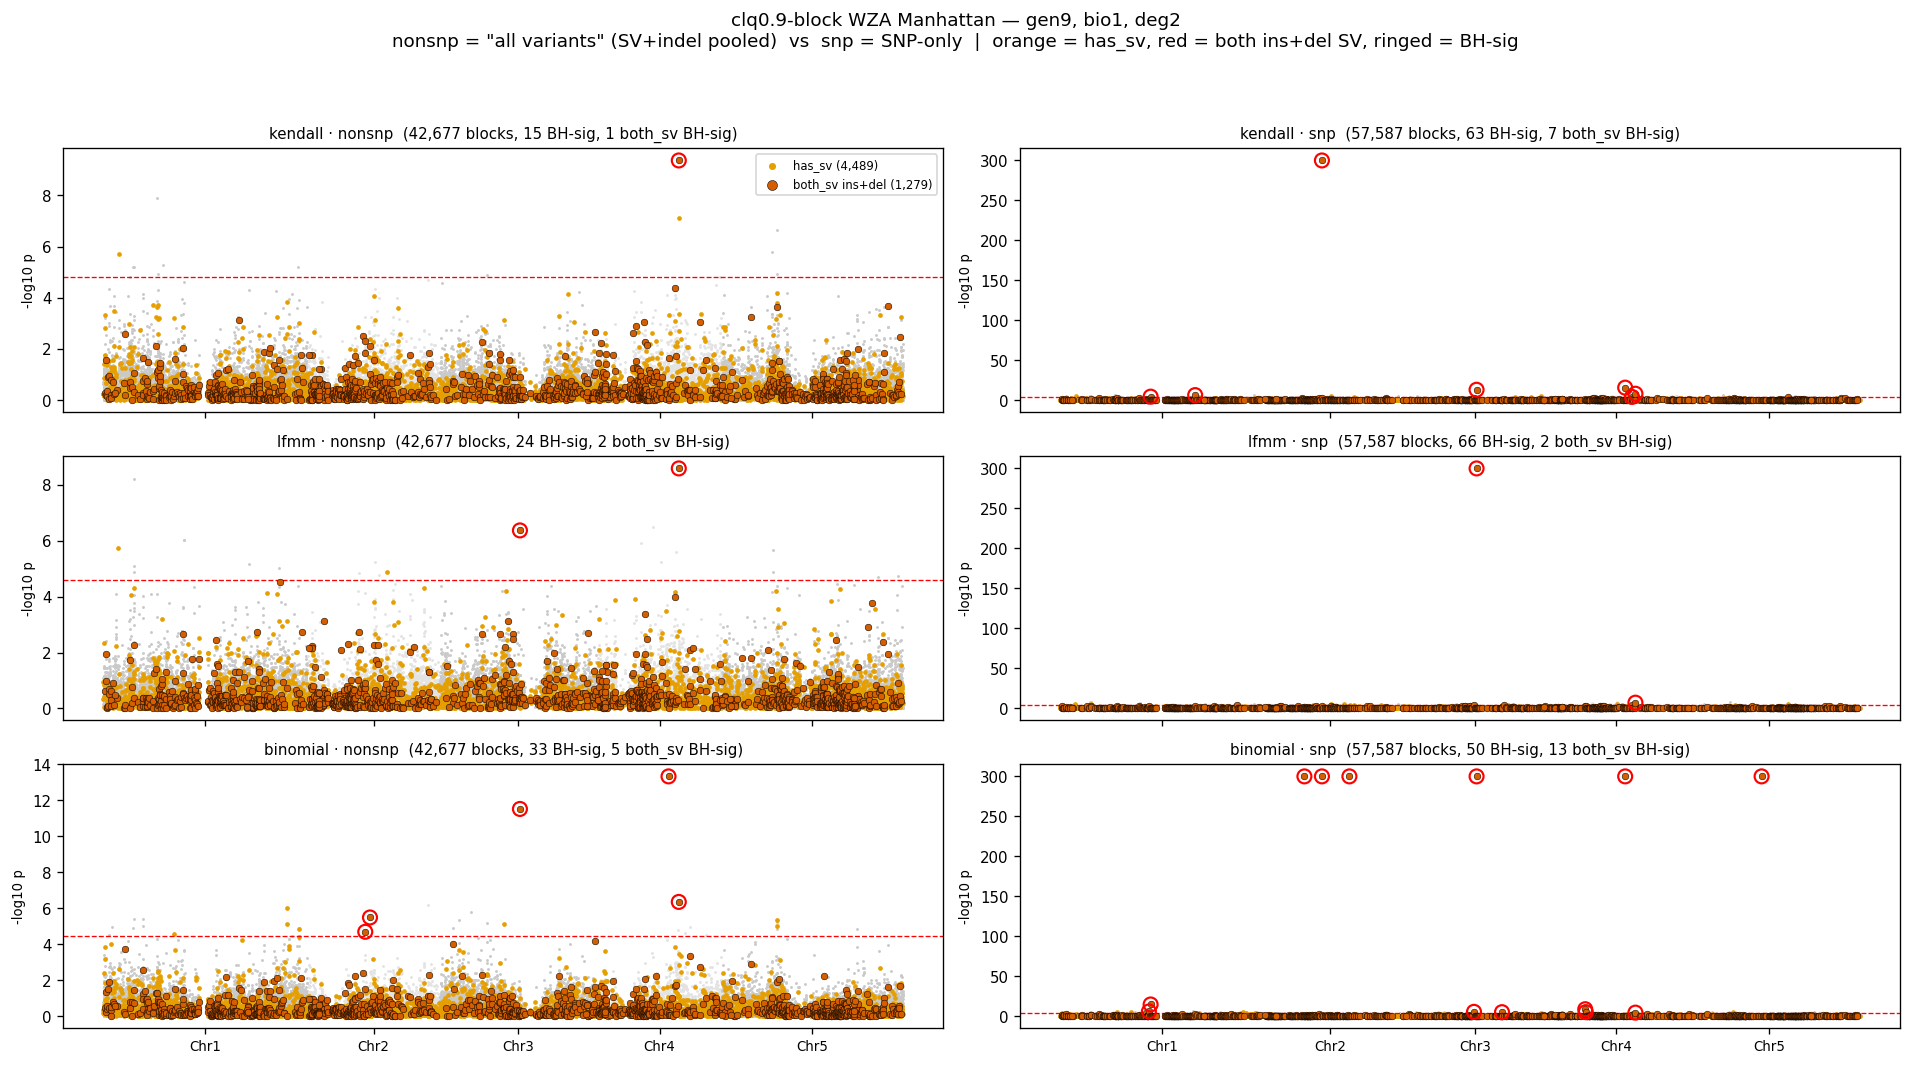

In [2]:

fig, axes = plt.subplots(len(MODELS), len(CLASSES), figsize=(16, 9), sharex=True)
for i, model in enumerate(MODELS):
    for j, cls in enumerate(CLASSES):
        ax = axes[i, j]
        f = f"{WZA}/wza_{model}_{cls}_gen9_bio1_deg2.csv"
        w = pd.read_csv(f).rename(columns={"index": "block", "Z_pVal": "pval"})
        w = w[np.isfinite(w.pval)].copy()
        w["q"] = bh(w.pval.to_numpy())
        w = w.merge(pol_full[["block","has_sv","both_sv"]], on="block", how="left")
        w = w[w.chrom.isin(OFF)].copy()
        w["gx"] = w.chrom.map(OFF) + w.pos
        w["mlp"] = -np.log10(w.pval.clip(lower=1e-300))

        # background: alternating chromosome colour, all blocks
        for k, c in enumerate(["Chr1","Chr2","Chr3","Chr4","Chr5"]):
            s = w[(w.chrom == c) & ~w.has_sv]
            ax.scatter(s.gx, s.mlp, s=3, color=("#c9c9c9", "#e3e3e3")[k % 2],
                       rasterized=True, linewidths=0, zorder=1)
        # has_sv blocks (single polarity or none) in orange
        s = w[w.has_sv & ~w.both_sv]
        ax.scatter(s.gx, s.mlp, s=8, color="#E69F00", rasterized=True, linewidths=0,
                   zorder=2, label=f"has_sv ({len(s):,})")
        # both-polarity SV blocks in red -- the enrichment-positive category
        s = w[w.both_sv]
        ax.scatter(s.gx, s.mlp, s=16, color="#D55E00", edgecolors="black", linewidths=0.3,
                   zorder=3, label=f"both_sv ins+del ({len(s):,})")
        # ring the BH-sig both_sv blocks
        sig_both = s[s.q < 0.05]
        if len(sig_both):
            ax.scatter(sig_both.gx, sig_both.mlp, s=70, facecolors="none",
                       edgecolors="red", linewidths=1.3, zorder=4)

        qthr = w.loc[w.q < 0.05, "pval"].max() if (w.q < 0.05).any() else None
        if qthr is not None:
            ax.axhline(-np.log10(qthr), color="red", ls="--", lw=0.8)
        nsig = int((w.q < 0.05).sum()); nsig_both = int((s.q < 0.05).sum())
        ax.set_title(f"{model} · {cls}  ({len(w):,} blocks, {nsig} BH-sig, "
                     f"{nsig_both} both_sv BH-sig)", fontsize=9)
        ax.set_ylabel("-log10 p", fontsize=8)
        if i == 0 and j == 0:
            ax.legend(fontsize=7, loc="upper right", markerscale=1.5)

for j, cls in enumerate(CLASSES):
    axes[-1, j].set_xticks([OFF[c] + CHROM_LEN[c] / 2 for c in OFF])
    axes[-1, j].set_xticklabels(list(OFF), fontsize=8)
fig.suptitle("clq0.9-block WZA Manhattan — gen9, bio1, deg2\n"
             "nonsnp = \"all variants\" (SV+indel pooled)  vs  snp = SNP-only  |  "
             "orange = has_sv, red = both ins+del SV, ringed = BH-sig", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.94])
out = f"{GEA}/phase1_replication/clq90/manhattan_sv_polarity_clq90.png"
fig.savefig(out, dpi=140)
print("wrote", out)
plt.show()


### Reading
- Left column (`nonsnp` = all variants beyond SNP) vs right column (`snp`-only) — same block
  coordinates, independently-computed p-values.
- Orange points (`has_sv`, single polarity or no SV) sit on the same distribution as the grey
  background — no visible enrichment, matching the McNemar null.
- Red points (`both_sv`, co-occurring insertion + deletion SV in the block) are sparse (~1,279
  of 42,677 nonsnp blocks) but disproportionately ring the top of the distribution in **both**
  classes — the cross-class replication behind the permutation-significant result.
- Ringed points are the 7 `both_sv` blocks that reach BH q<0.05 in at least one model
  (`Chr1_13659`, `Chr1_7059`, `Chr2_2819`, `Chr2_3115`, `Chr2_5040`, `Chr3_6144`, `Chr4_6307`).
  `Chr2_2819`/`Chr3_6144`/`Chr4_6307` are the same loci independently flagged as the most
  reproducible climate blocks (BH-sig in all 3 models, both classes) in `STATUS_clq90.md`.
- Caveat: `both_sv` may partly proxy for total SV density rather than polarity per se —
  not yet tested as a continuous covariate.